# One-node Reservoir

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from modules.IGT_Simulation import create_pulse_train, generate_single_out_current
from modules.load_MNIST import get_images_batch
from modules.One_Node_Reservoir import reconstruct_images
from modules.image_utils import downscale_images, binarize_images

%load_ext autoreload
%autoreload 2

np.set_printoptions(threshold=np.inf)
rng = np.random.default_rng(seed=42)

In [2]:
THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
VOLTAGE = 2.5
CURVATURE = 1

IMAGE_THRESHOLD = 60

TIME_RESOLUTION = 0.2
BETA = 0.56
TAU = 2.6 #ms
K = 700 #nA

# TIME_RESOLUTION = 0.2
# K = 400
# BETA = 0.65
# TAU = 3.00

NEURON_COUNT = 1

TRAIN_BATCH_SIZE = 60000
TEST_BATCH_SIZE = 10000

MAX_ITERATION = 20
LEARNING_RATE = 2

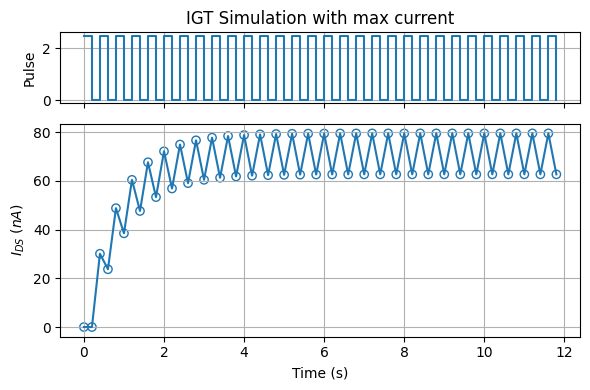

In [3]:
max_pulse = create_pulse_train(0, VOLTAGE, 1, 1, 30)

max_current = np.max(generate_single_out_current(max_pulse, K, BETA, TAU, TIME_RESOLUTION, True, "IGT Simulation with max current"))

In [4]:
images, labels = get_images_batch(TRAIN_BATCH_SIZE, rng=rng, one_hot=False)

reconstructed_images = reconstruct_images(images, max_current, k=K, beta=BETA, tau=TAU, time_resolution=TIME_RESOLUTION)

downscaled_images = downscale_images(binarize_images(images, threshold=IMAGE_THRESHOLD), (14, 7))
downscaled_images = np.array(downscaled_images).reshape(len(downscaled_images), 14*7)

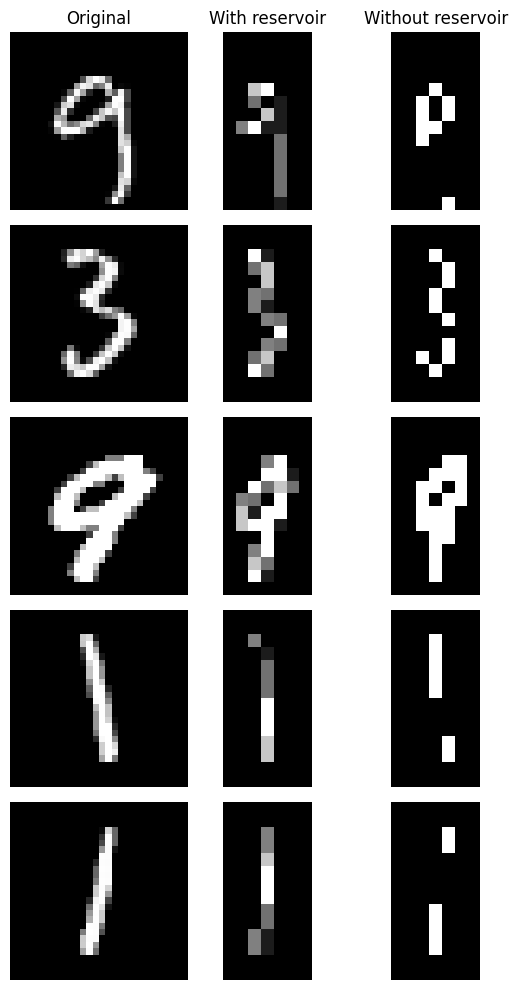

In [5]:
fig, axes = plt.subplots(len(reconstructed_images[:5]), 3, figsize=(5.5, 2*len(reconstructed_images[:5])))

axes[0, 0].set_title("Original")
axes[0, 1].set_title("With reservoir")
axes[0, 2].set_title("Without reservoir")

for i in range(5):
    axes[i, 0].imshow(images[i], cmap="binary_r")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(reconstructed_images[i].reshape(14, 7), cmap="binary_r")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(downscaled_images[i].reshape(14, 7), cmap="binary_r")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [6]:
model_reservoir_mlp = MLPClassifier(
    hidden_layer_sizes=(),
    activation="logistic",
    solver="sgd",
    learning_rate="constant",
    learning_rate_init=LEARNING_RATE,
    batch_size=600,
    max_iter=MAX_ITERATION,
    random_state=42
)

model_reservoir_mlp.fit(reconstructed_images, labels)

model_mlp = MLPClassifier(
    hidden_layer_sizes=(),
    activation="logistic",
    solver="sgd",
    learning_rate="constant",
    learning_rate_init=LEARNING_RATE,
    batch_size=600,
    max_iter=MAX_ITERATION,
    random_state=42
)

model_mlp.fit(downscaled_images, labels)

C:\Users\filipi2610041\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\filipi2610041\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.",()
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",600
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",2
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",20
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [7]:
images_test, labels_test = get_images_batch(TEST_BATCH_SIZE, rng=rng, mode="TEST", one_hot=False)

reconstructed_test_images = reconstruct_images(images_test, max_current, k=K, beta=BETA, tau=TAU, time_resolution=TIME_RESOLUTION)

downscaled_test_images = downscale_images(binarize_images(images_test, threshold=IMAGE_THRESHOLD), (14, 7))
downscaled_test_images = np.array(downscaled_test_images).reshape(len(downscaled_test_images), 14*7)

accuracy_reservoir = model_reservoir_mlp.score(reconstructed_test_images, labels_test)
accuracy_no_reservoir = model_mlp.score(downscaled_test_images, labels_test)

print(f"Accuracy w/ Reservoir  : {(100*accuracy_reservoir):2f}%")
print(f"Accuracy wo/ Reservoir : {(100*accuracy_no_reservoir):2f}%")

Accuracy w/ Reservoir  : 87.710000%
Accuracy wo/ Reservoir : 81.840000%


In [8]:
model_reservoir_lr = LogisticRegression(
    max_iter=MAX_ITERATION
)

model_reservoir_lr.fit(reconstructed_images, labels)

model_no_reservoir_lr= LogisticRegression(
    max_iter=MAX_ITERATION
)

model_no_reservoir_lr.fit(downscaled_images, labels)

C:\Users\filipi2610041\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\filipi2610041\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=20).
You might also want to scale the data as shown in:
    https://scikit-learn.or

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",20
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [9]:
accuracy_reservoir = model_reservoir_lr.score(reconstructed_test_images, labels_test)
accuracy_no_reservoir = model_no_reservoir_lr.score(downscaled_test_images, labels_test)

print(f"Accuracy w/ Reservoir  : {(100*accuracy_reservoir):2f}%")
print(f"Accuracy wo/ Reservoir : {(100*accuracy_no_reservoir):2f}%")

Accuracy w/ Reservoir  : 85.760000%
Accuracy wo/ Reservoir : 81.620000%


In [10]:
class Readout(nn.Module):

    def __init__(self):
        super().__init__()

        
        self.net = nn.Sequential(
            nn.Linear(98,10)
        )


    def forward(self, x):
        return self.net(x)

model_reservoir_pytorch = Readout()
model_no_reservoir_pytorch = Readout()

criterion = nn.CrossEntropyLoss()

optimizer_reservoir = torch.optim.SGD(
    model_reservoir_pytorch.parameters(),
    lr=LEARNING_RATE
)

optimizer_no_reservoir = torch.optim.SGD(
    model_no_reservoir_pytorch.parameters(),
    lr=LEARNING_RATE
)

In [11]:
X_train_tensor_reservoir = torch.tensor(reconstructed_images, dtype=torch.float32)
X_train_tensor_no_reservoir = torch.tensor(downscaled_images, dtype=torch.float32)

y_train_tensor = torch.tensor(labels, dtype=torch.long)

dataset_reservoir = TensorDataset(
    X_train_tensor_reservoir,
    y_train_tensor
)
dataset_no_reservoir = TensorDataset(
    X_train_tensor_no_reservoir,
    y_train_tensor
)

loader_reservoir = DataLoader(
    dataset_reservoir,
    batch_size=600,
    shuffle=True
)
loader_no_reservoir = DataLoader(
    dataset_no_reservoir,
    batch_size=600,
    shuffle=True
)

C:\Users\filipi2610041\AppData\Local\Temp\ipykernel_15208\3837389742.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  X_train_tensor_reservoir = torch.tensor(reconstructed_images, dtype=torch.float32)


In [12]:
loss_reservoir = []
loss_no_reservoir = []

for epoch in range(MAX_ITERATION):
    running_loss_reservoir = 0
    running_loss_no_reservoir = 0

    for x_batch, y_batch in loader_reservoir:
        optimizer_reservoir.zero_grad()
        outputs = model_reservoir_pytorch(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_reservoir.step()
        running_loss_reservoir += loss.item()

    for x_batch, y_batch in loader_no_reservoir:
        optimizer_no_reservoir.zero_grad()
        outputs = model_no_reservoir_pytorch(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_no_reservoir.step()
        running_loss_no_reservoir += loss.item()

    print(f"\rEpoch {epoch+1}: {running_loss_no_reservoir:.3f} wo/ reservoir | {running_loss_reservoir:.3f} w/ reservoir", end="")

    loss_reservoir.append(running_loss_reservoir)
    loss_no_reservoir.append(running_loss_no_reservoir)


Epoch 20: 57.091 wo/ reservoir | 54.043 w/ reservoir

Accuracy w/ Reservoir  : 85.670000%
Accuracy wo/ Reservoir : 82.570000%


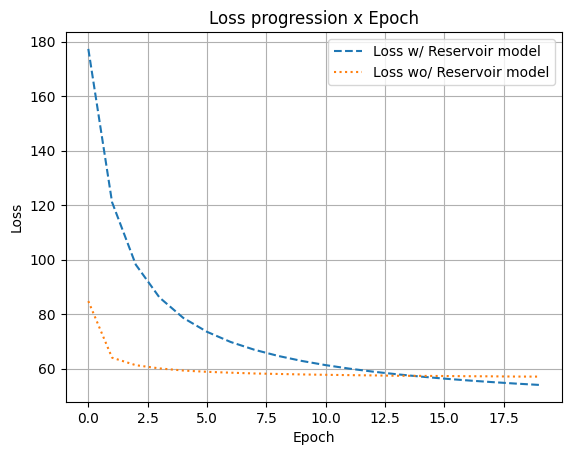

In [13]:
X_test_tensor_reservoir = torch.tensor(
    reconstructed_test_images,
    dtype=torch.float32
)

model_reservoir_pytorch.eval()

with torch.no_grad():
    outputs = model_reservoir_pytorch(X_test_tensor_reservoir)
    preds = outputs.argmax(dim=1)

accuracy_reservoir = (preds.numpy() == labels_test).mean()

#------------------

X_test_tensor = torch.tensor(
    downscaled_test_images,
    dtype=torch.float32
)

model_no_reservoir_pytorch.eval()

with torch.no_grad():
    outputs = model_no_reservoir_pytorch(X_test_tensor)
    preds = outputs.argmax(dim=1)

accuracy = (preds.numpy() == labels_test).mean()

print(f"Accuracy w/ Reservoir  : {(100*accuracy_reservoir):2f}%")
print(f"Accuracy wo/ Reservoir : {(100*accuracy):2f}%")

plt.plot(range(MAX_ITERATION), loss_reservoir, label="Loss w/ Reservoir model", linestyle="--")
plt.plot(range(MAX_ITERATION), loss_no_reservoir, label="Loss wo/ Reservoir model", linestyle=":")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss progression x Epoch")
plt.grid()
plt.legend()
plt.show()